# Case Mr. Health

O Forecasting consolida dados, realiza EDA, cria atributos temporais, compara modelos e gera previsão de demanda.


In [2]:
import json
import math
import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

RANDOM_STATE = 42
HORIZONTE_TESTE = 14
HORIZONTE_PREVISAO = 7
PASTA_SAIDA = Path('resultados_mr_health')
PASTA_SAIDA.mkdir(exist_ok=True)

## 1. Upload das planilhas

In [3]:
try:
    from google.colab import files
    uploaded = files.upload()
    print('Arquivos recebidos:', list(uploaded.keys()))

Saving ITEM_PEDIDO-_2_.xlsx to ITEM_PEDIDO-_2_.xlsx
Saving ITENS-_3_.xlsx to ITENS-_3_.xlsx
Saving PEDIDO-_1_.xlsx to PEDIDO-_1_.xlsx
Arquivos recebidos: ['ITEM_PEDIDO-_2_.xlsx', 'ITENS-_3_.xlsx', 'PEDIDO-_1_.xlsx']


In [4]:
def localizar_arquivo(palavras):
    candidatos = list(Path('.').glob('*.xlsx'))
    for caminho in candidatos:
        nome = caminho.name.upper()
        if all(p.upper() in nome for p in palavras):
            return caminho
    raise FileNotFoundError(f'Arquivo não encontrado para os termos: {palavras}')

ARQ_PEDIDO = next(p for p in Path('.').glob('*.xlsx') if 'PEDIDO' in p.name.upper() and 'ITEM' not in p.name.upper())
ARQ_ITEM_PEDIDO = localizar_arquivo(['ITEM', 'PEDIDO'])
# Evita selecionar ITEM_PEDIDO como cadastro de itens.
ARQ_ITENS = next(
    p for p in Path('.').glob('*.xlsx')
    if 'ITENS' in p.name.upper() and 'PEDIDO' not in p.name.upper()
)

print('PEDIDO:', ARQ_PEDIDO)
print('ITEM_PEDIDO:', ARQ_ITEM_PEDIDO)
print('ITENS:', ARQ_ITENS)

PEDIDO: PEDIDO-_1_.xlsx
ITEM_PEDIDO: ITEM_PEDIDO-_2_.xlsx
ITENS: ITENS-_3_.xlsx


## 2. Leitura, padronização e validações iniciais

In [5]:
def normalizar_coluna(c):
    return str(c).strip().upper().replace(' ', '_')

pedido = pd.read_excel(ARQ_PEDIDO)
item_pedido = pd.read_excel(ARQ_ITEM_PEDIDO)
itens = pd.read_excel(ARQ_ITENS)

pedido.columns = [normalizar_coluna(c) for c in pedido.columns]
item_pedido.columns = [normalizar_coluna(c) for c in item_pedido.columns]
itens.columns = [normalizar_coluna(c) for c in itens.columns]

# Remove apenas colunas de índice exportadas nas duas tabelas transacionais.
pedido = pedido.loc[:, ~pedido.columns.str.startswith('UNNAMED')].copy()
item_pedido = item_pedido.loc[:, ~item_pedido.columns.str.startswith('UNNAMED')].copy()

# O cadastro ITENS veio com cabeçalho irregular; as duas colunas são item e preço.
if itens.shape[1] != 2:
    raise ValueError(f'ITENS deveria possuir 2 colunas, mas possui {itens.shape[1]}.')
itens.columns = ['ID_ITEM', 'PRECO_UNITARIO']

pedido['ID_PEDIDO'] = pd.to_numeric(pedido['ID_PEDIDO'], errors='raise').astype('int64')
pedido['DATA'] = pd.to_datetime(pedido['DATA'], errors='raise')
pedido['VALOR_TOTAL'] = pd.to_numeric(pedido['VALOR_TOTAL'], errors='coerce')

item_pedido['ID_PEDIDO'] = pd.to_numeric(item_pedido['ID_PEDIDO'], errors='raise').astype('int64')
item_pedido['ID_ITEM'] = item_pedido['ID_ITEM'].astype(str).str.strip()
item_pedido['QUANTIDADE'] = pd.to_numeric(item_pedido['QUANTIDADE'], errors='raise')

itens['ID_ITEM'] = itens['ID_ITEM'].astype(str).str.strip()
itens['PRECO_UNITARIO'] = pd.to_numeric(itens['PRECO_UNITARIO'], errors='raise')

print('PEDIDO')
display(pedido.head())
print('ITEM_PEDIDO')
display(item_pedido.head())
print('ITENS')
display(itens)

PEDIDO


,ID_PEDIDO,DATA,VALOR_TOTAL
0,120210601,2021-06-01,NaN
1,220210601,2021-06-01,NaN
2,320210604,2021-06-04,NaN
3,420210604,2021-06-04,NaN
4,520210604,2021-06-04,NaN


ITEM_PEDIDO


,ID_PEDIDO,ID_ITEM,QUANTIDADE
0,120210601,item C,4
1,220210601,item A,3
2,320210604,item C,1
3,420210604,item B,4
4,420210604,item C,2


ITENS


,ID_ITEM,PRECO_UNITARIO
0,item A,10
1,item B,15
2,item C,20
3,item D,25


In [6]:
def diagnostico_df(nome, df):
    return pd.DataFrame({
        'tabela': nome,
        'linhas': len(df),
        'colunas': df.shape[1],
        'duplicadas_exatas': df.duplicated().sum(),
        'celulas_nulas': int(df.isna().sum().sum()),
    }, index=[0])

qualidade_tabelas = pd.concat([
    diagnostico_df('PEDIDO', pedido),
    diagnostico_df('ITEM_PEDIDO', item_pedido),
    diagnostico_df('ITENS', itens),
], ignore_index=True)

grupo_repetido = (
    item_pedido.groupby(['ID_PEDIDO', 'ID_ITEM']).size().reset_index(name='N_LINHAS')
)

diagnostico = {
    'pedidos_unicos': int(pedido['ID_PEDIDO'].nunique()),
    'id_pedido_duplicado': int(pedido['ID_PEDIDO'].duplicated().sum()),
    'valor_total_nulo': int(pedido['VALOR_TOTAL'].isna().sum()),
    'linhas_item_pedido': int(len(item_pedido)),
    'grupos_pedido_item_repetidos': int((grupo_repetido['N_LINHAS'] > 1).sum()),
    'itens_cadastrados': int(itens['ID_ITEM'].nunique()),
    'pedidos_sem_itens': int(len(set(pedido.ID_PEDIDO) - set(item_pedido.ID_PEDIDO))),
    'linhas_com_pedido_inexistente': int(len(set(item_pedido.ID_PEDIDO) - set(pedido.ID_PEDIDO))),
    'data_minima': str(pedido.DATA.min().date()),
    'data_maxima': str(pedido.DATA.max().date()),
}

display(qualidade_tabelas)
display(pd.Series(diagnostico, name='resultado').to_frame())

,tabela,linhas,colunas,duplicadas_exatas,celulas_nulas
0,PEDIDO,181,3,0,181
1,ITEM_PEDIDO,295,3,4,0
2,ITENS,4,2,0,0


,resultado
pedidos_unicos,181
id_pedido_duplicado,0
valor_total_nulo,181
linhas_item_pedido,295
grupos_pedido_item_repetidos,15
itens_cadastrados,4
pedidos_sem_itens,0
linhas_com_pedido_inexistente,0
data_minima,2021-06-01
data_maxima,2021-09-01


In [7]:
item_consolidado = (
    item_pedido.groupby(['ID_PEDIDO', 'ID_ITEM'], as_index=False)['QUANTIDADE'].sum()
)

base = (
    item_consolidado
    .merge(itens, on='ID_ITEM', how='left', validate='many_to_one')
    .merge(pedido[['ID_PEDIDO', 'DATA']], on='ID_PEDIDO', how='left', validate='many_to_one')
)

if base['PRECO_UNITARIO'].isna().any():
    raise ValueError('Existem itens sem preço cadastrado.')
if base['DATA'].isna().any():
    raise ValueError('Existem itens associados a pedidos inexistentes.')

base['VALOR_ITEM'] = base['QUANTIDADE'] * base['PRECO_UNITARIO']

totais = base.groupby('ID_PEDIDO', as_index=False)['VALOR_ITEM'].sum().rename(
    columns={'VALOR_ITEM': 'VALOR_TOTAL_CALCULADO'}
)
pedidos = pedido.merge(totais, on='ID_PEDIDO', how='left', validate='one_to_one')
pedidos['VALOR_TOTAL_FINAL'] = pedidos['VALOR_TOTAL'].fillna(pedidos['VALOR_TOTAL_CALCULADO'])

print('Base consolidada:')
display(base.head())
print('Pedidos com valor reconstruído:')
display(pedidos.head())

Base consolidada:


,ID_PEDIDO,ID_ITEM,QUANTIDADE,PRECO_UNITARIO,DATA,VALOR_ITEM
0,120210601,item C,4,20,2021-06-01,80
1,220210601,item A,3,10,2021-06-01,30
2,320210604,item C,1,20,2021-06-04,20
3,420210604,item B,4,15,2021-06-04,60
4,420210604,item C,2,20,2021-06-04,40


Pedidos com valor reconstruído:


,ID_PEDIDO,DATA,VALOR_TOTAL,VALOR_TOTAL_CALCULADO,VALOR_TOTAL_FINAL
0,120210601,2021-06-01,NaN,80,80.000
1,220210601,2021-06-01,NaN,30,30.000
2,320210604,2021-06-04,NaN,20,20.000
3,420210604,2021-06-04,NaN,100,100.000
4,520210604,2021-06-04,NaN,30,30.000


## 3. Análise exploratória de dados

In [8]:
resumo_kpis = pd.Series({
    'Pedidos': pedidos['ID_PEDIDO'].nunique(),
    'Produtos': base['ID_ITEM'].nunique(),
    'Quantidade total': base['QUANTIDADE'].sum(),
    'Receita reconstruída': base['VALOR_ITEM'].sum(),
    'Ticket médio': pedidos['VALOR_TOTAL_FINAL'].mean(),
    'Ticket mediano': pedidos['VALOR_TOTAL_FINAL'].median(),
    'Data inicial': pedidos['DATA'].min().date(),
    'Data final': pedidos['DATA'].max().date(),
}, name='Valor')
display(resumo_kpis.to_frame())

,Valor
Pedidos,181
Produtos,4
Quantidade total,895
Receita reconstruída,15960
Ticket médio,88.177
Ticket mediano,75.000
Data inicial,2021-06-01
Data final,2021-09-01


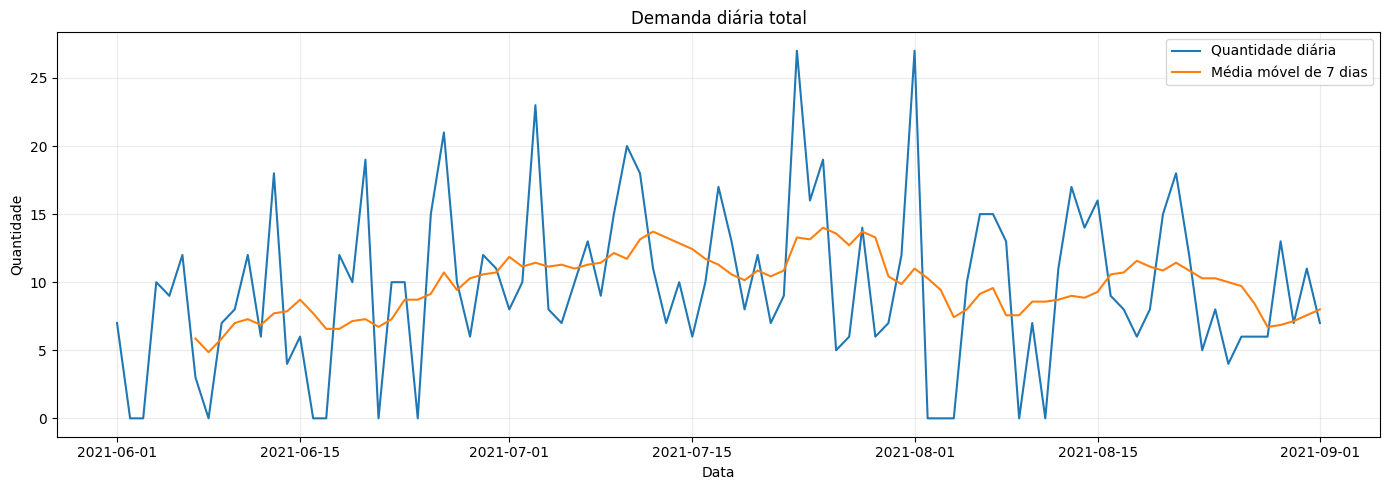

In [9]:
# Série diária completa por produto.
demanda_obs = base.groupby(['DATA', 'ID_ITEM'], as_index=False)['QUANTIDADE'].sum()
datas = pd.date_range(demanda_obs.DATA.min(), demanda_obs.DATA.max(), freq='D')
produtos = sorted(demanda_obs.ID_ITEM.unique())
grade = pd.MultiIndex.from_product([datas, produtos], names=['DATA', 'ID_ITEM']).to_frame(index=False)
demanda = grade.merge(demanda_obs, on=['DATA', 'ID_ITEM'], how='left')
demanda['QUANTIDADE'] = demanda['QUANTIDADE'].fillna(0.0)

diaria_total = demanda.groupby('DATA', as_index=False)['QUANTIDADE'].sum()
diaria_total['MEDIA_MOVEL_7D'] = diaria_total['QUANTIDADE'].rolling(7).mean()

plt.figure(figsize=(14, 5))
plt.plot(diaria_total.DATA, diaria_total.QUANTIDADE, label='Quantidade diária')
plt.plot(diaria_total.DATA, diaria_total.MEDIA_MOVEL_7D, label='Média móvel de 7 dias')
plt.title('Demanda diária total')
plt.xlabel('Data')
plt.ylabel('Quantidade')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

,ID_ITEM,QUANTIDADE,RECEITA,PRECO,PARTICIPACAO_RECEITA,PARTICIPACAO_ACUMULADA,CLASSE_ABC
3,item D,251,6275,25,0.393,0.393,A
2,item C,216,4320,20,0.271,0.664,A
1,item B,217,3255,15,0.204,0.868,B
0,item A,211,2110,10,0.132,1.000,C


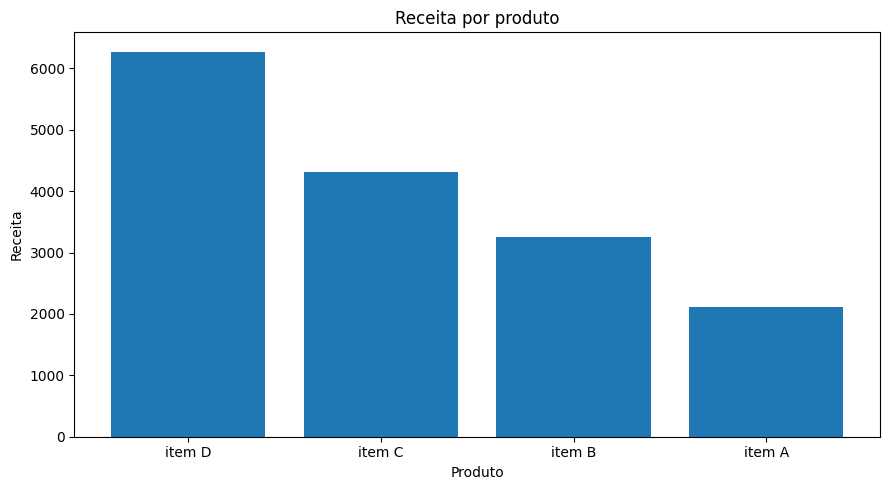

In [10]:
por_item = base.groupby('ID_ITEM', as_index=False).agg(
    QUANTIDADE=('QUANTIDADE', 'sum'),
    RECEITA=('VALOR_ITEM', 'sum'),
    PRECO=('PRECO_UNITARIO', 'first')
).sort_values('RECEITA', ascending=False)
por_item['PARTICIPACAO_RECEITA'] = por_item['RECEITA'] / por_item['RECEITA'].sum()
por_item['PARTICIPACAO_ACUMULADA'] = por_item['PARTICIPACAO_RECEITA'].cumsum()
por_item['CLASSE_ABC'] = np.select(
    [por_item['PARTICIPACAO_ACUMULADA'] <= 0.80,
     por_item['PARTICIPACAO_ACUMULADA'] <= 0.95],
    ['A', 'B'], default='C'
)
display(por_item)

plt.figure(figsize=(9, 5))
plt.bar(por_item.ID_ITEM, por_item.RECEITA)
plt.title('Receita por produto')
plt.xlabel('Produto')
plt.ylabel('Receita')
plt.tight_layout()
plt.show()

,DIA,QUANTIDADE
0,Segunda,5.000
1,Terça,7.429
2,Quarta,6.357
3,Quinta,6.231
4,Sexta,13.154
5,Sábado,14.385
6,Domingo,15.231


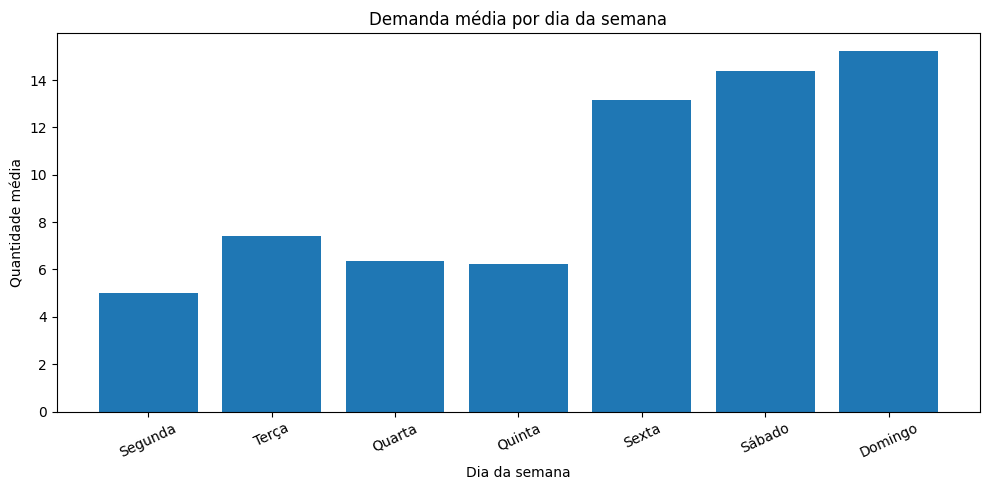

In [11]:
nomes_dias = {0:'Segunda',1:'Terça',2:'Quarta',3:'Quinta',4:'Sexta',5:'Sábado',6:'Domingo'}
diaria_total['DIA_NUM'] = diaria_total.DATA.dt.dayofweek
por_dia = diaria_total.groupby('DIA_NUM', as_index=False)['QUANTIDADE'].mean()
por_dia['DIA'] = por_dia.DIA_NUM.map(nomes_dias)
display(por_dia[['DIA', 'QUANTIDADE']])

plt.figure(figsize=(10, 5))
plt.bar(por_dia.DIA, por_dia.QUANTIDADE)
plt.title('Demanda média por dia da semana')
plt.xlabel('Dia da semana')
plt.ylabel('Quantidade média')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

,MES,PEDIDOS,RECEITA
0,2021-06,54,"4,165.000"
1,2021-07,71,"6,525.000"
2,2021-08,54,"5,130.000"
3,2021-09,2,140.000


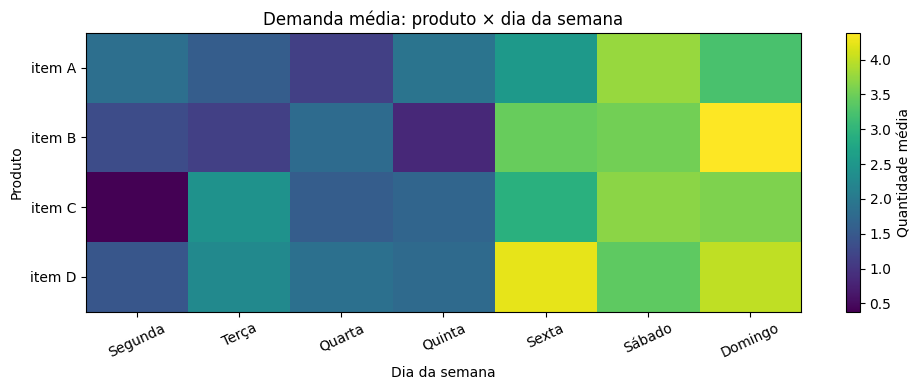

In [12]:
mensal = pedidos.assign(MES=pedidos.DATA.dt.to_period('M').astype(str)).groupby('MES', as_index=False).agg(
    PEDIDOS=('ID_PEDIDO', 'nunique'),
    RECEITA=('VALOR_TOTAL_FINAL', 'sum')
)
display(mensal)

# Heatmap sem seaborn: média de demanda por produto e dia da semana.
heat = demanda.assign(DIA_NUM=demanda.DATA.dt.dayofweek).pivot_table(
    index='ID_ITEM', columns='DIA_NUM', values='QUANTIDADE', aggfunc='mean'
).reindex(columns=range(7))

plt.figure(figsize=(10, 4))
img = plt.imshow(heat.values, aspect='auto')
plt.colorbar(img, label='Quantidade média')
plt.xticks(range(7), [nomes_dias[i] for i in range(7)], rotation=25)
plt.yticks(range(len(heat.index)), heat.index)
plt.title('Demanda média: produto × dia da semana')
plt.xlabel('Dia da semana')
plt.ylabel('Produto')
plt.tight_layout()
plt.show()

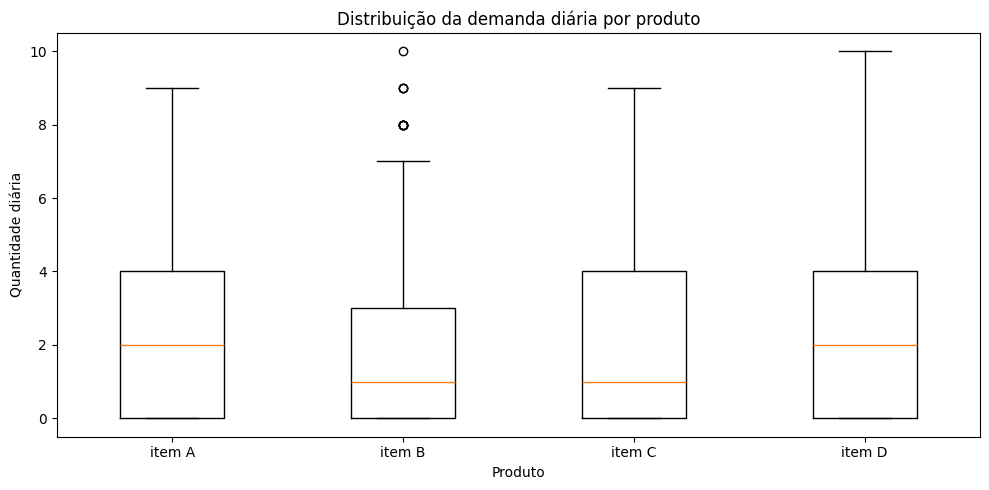

,ID_ITEM,LIMITE_SUPERIOR_IQR,DIAS_ACIMA
0,item A,10.000,0
1,item B,7.500,10
2,item C,10.000,0
3,item D,10.000,0


In [13]:
# Distribuição e boxplot da demanda diária por produto.
plt.figure(figsize=(10, 5))
series = [demanda.loc[demanda.ID_ITEM == item, 'QUANTIDADE'] for item in produtos]
plt.boxplot(series, labels=produtos, showfliers=True)
plt.title('Distribuição da demanda diária por produto')
plt.xlabel('Produto')
plt.ylabel('Quantidade diária')
plt.tight_layout()
plt.show()

# Outliers pela regra do IQR, apenas como diagnóstico (não removemos automaticamente).
outliers = []
for item, g in demanda.groupby('ID_ITEM'):
    q1, q3 = g.QUANTIDADE.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite = q3 + 1.5 * iqr
    outliers.append({'ID_ITEM': item, 'LIMITE_SUPERIOR_IQR': limite, 'DIAS_ACIMA': int((g.QUANTIDADE > limite).sum())})
display(pd.DataFrame(outliers))

## 4. Engenharia de atributos

`shift` para que a previsão de um dia não utilize informação do próprio dia ou do futuro.

In [14]:
precos = itens.set_index('ID_ITEM')['PRECO_UNITARIO'].to_dict()
frames = []
for item, g in demanda.groupby('ID_ITEM'):
    g = g.sort_values('DATA').copy()
    g['INDICE_TEMPO'] = np.arange(len(g))
    g['DIA_SEMANA'] = g.DATA.dt.dayofweek.astype(str)
    g['MES'] = g.DATA.dt.month.astype(str)
    g['SEMANA_ANO'] = g.DATA.dt.isocalendar().week.astype(int)
    g['FIM_SEMANA'] = (g.DATA.dt.dayofweek >= 5).astype(int)
    g['PRECO_UNITARIO'] = float(precos[item])
    g['LAG_1'] = g.QUANTIDADE.shift(1)
    g['LAG_7'] = g.QUANTIDADE.shift(7)
    g['LAG_14'] = g.QUANTIDADE.shift(14)
    g['MEDIA_7'] = g.QUANTIDADE.shift(1).rolling(7).mean()
    g['MEDIA_14'] = g.QUANTIDADE.shift(1).rolling(14).mean()
    g['STD_7'] = g.QUANTIDADE.shift(1).rolling(7).std()
    g['MIN_7'] = g.QUANTIDADE.shift(1).rolling(7).min()
    g['MAX_7'] = g.QUANTIDADE.shift(1).rolling(7).max()
    frames.append(g)

features = pd.concat(frames, ignore_index=True).dropna().sort_values(['DATA','ID_ITEM']).reset_index(drop=True)
print('Linhas disponíveis para modelagem:', len(features))
display(features.head())

Linhas disponíveis para modelagem: 316


,DATA,ID_ITEM,QUANTIDADE,INDICE_TEMPO,DIA_SEMANA,MES,SEMANA_ANO,FIM_SEMANA,PRECO_UNITARIO,LAG_1,LAG_7,LAG_14,MEDIA_7,MEDIA_14,STD_7,MIN_7,MAX_7
0,2021-06-15,item A,0.000,14,1,6,24,0,10.000,0.000,0.000,3.000,0.857,1.143,1.464,0.000,4.000
1,2021-06-15,item B,4.000,14,1,6,24,0,15.000,2.000,0.000,0.000,2.143,2.357,1.773,0.000,5.000
2,2021-06-15,item C,0.000,14,1,6,24,0,20.000,0.000,0.000,4.000,1.286,1.429,1.890,0.000,4.000
3,2021-06-15,item D,2.000,14,1,6,24,0,25.000,2.000,0.000,0.000,3.571,1.929,3.735,0.000,10.000
4,2021-06-16,item A,0.000,15,2,6,24,0,10.000,0.000,1.000,0.000,0.857,0.929,1.464,0.000,4.000


## 5. Modelos, baselines e validação temporal

In [15]:
CATEGORICAS = ['ID_ITEM', 'DIA_SEMANA', 'MES']
NUMERICAS = ['INDICE_TEMPO','SEMANA_ANO','FIM_SEMANA','PRECO_UNITARIO','LAG_1','LAG_7','LAG_14','MEDIA_7','MEDIA_14','STD_7','MIN_7','MAX_7']
COLUNAS_MODELO = CATEGORICAS + NUMERICAS

def criar_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def pipeline(modelo, escalar=False):
    passos_num = [('imputer', SimpleImputer(strategy='median'))]
    if escalar:
        passos_num.append(('scaler', StandardScaler()))
    prep = ColumnTransformer([
        ('cat', criar_ohe(), CATEGORICAS),
        ('num', Pipeline(passos_num), NUMERICAS)
    ])
    return Pipeline([('prep', prep), ('modelo', modelo)])

def modelos_candidatos():
    modelos = {
        'RegressaoLinear': pipeline(LinearRegression()),
        'Poisson': pipeline(PoissonRegressor(alpha=0.5, max_iter=2000), escalar=True),
        'RandomForest': pipeline(RandomForestRegressor(
            n_estimators=180, min_samples_leaf=6, max_features=0.7,
            random_state=RANDOM_STATE, n_jobs=-1)),
        'GradientBoosting': pipeline(GradientBoostingRegressor(
            n_estimators=120, learning_rate=0.03, max_depth=2,
            loss='huber', random_state=RANDOM_STATE)),
    }
    try:
        from xgboost import XGBRegressor
        modelos['XGBoost'] = pipeline(XGBRegressor(
            n_estimators=120, learning_rate=0.03, max_depth=3,
            subsample=0.8, colsample_bytree=0.8,
            objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1))
    except Exception as e:
        print('XGBoost indisponível:', e)
    return modelos

def metricas(y, p):
    y, p = np.asarray(y), np.clip(np.asarray(p), 0, None)
    mascara = y != 0
    mape = np.mean(np.abs((y[mascara] - p[mascara]) / y[mascara])) * 100 if mascara.any() else np.nan
    return {
        'MAE': mean_absolute_error(y, p),
        'RMSE': mean_squared_error(y, p) ** 0.5,
        'MAPE_SEM_ZEROS': mape,
        'R2': r2_score(y, p),
    }

def baseline_media_item(treino, avaliacao, por_dia=False):
    chaves = ['ID_ITEM','DIA_SEMANA'] if por_dia else ['ID_ITEM']
    medias = treino.groupby(chaves).QUANTIDADE.mean()
    fallback = treino.groupby('ID_ITEM').QUANTIDADE.mean()
    out=[]
    for r in avaliacao.itertuples(index=False):
        chave=(r.ID_ITEM,r.DIA_SEMANA) if por_dia else r.ID_ITEM
        v=medias.get(chave, np.nan)
        if pd.isna(v): v=fallback.get(r.ID_ITEM, treino.QUANTIDADE.mean())
        out.append(v)
    return np.array(out)

In [16]:
# Holdout final: últimos 14 dias. O período anterior é usado para seleção por backtesting.
data_max = features.DATA.max()
inicio_holdout = data_max - pd.Timedelta(days=HORIZONTE_TESTE - 1)
pre_holdout = features[features.DATA < inicio_holdout].copy()
holdout = features[features.DATA >= inicio_holdout].copy()

# Três janelas temporais consecutivas de 14 dias.
fim_pre = pre_holdout.DATA.max() + pd.Timedelta(days=1)
folds=[]
for deslocamento in range(3,0,-1):
    inicio = fim_pre - pd.Timedelta(days=14*deslocamento)
    fim = inicio + pd.Timedelta(days=14)
    folds.append((inicio,fim))

resultados=[]
erros_cv={}
for n,(ini,fim) in enumerate(folds,1):
    treino=pre_holdout[pre_holdout.DATA < ini]
    valid=pre_holdout[(pre_holdout.DATA >= ini)&(pre_holdout.DATA < fim)]
    if treino.empty or valid.empty: continue
    Xtr,ytr=treino[COLUNAS_MODELO],treino.QUANTIDADE
    Xv,yv=valid[COLUNAS_MODELO],valid.QUANTIDADE
    for nome,mod in modelos_candidatos().items():
        mod.fit(Xtr,ytr)
        pred=np.clip(mod.predict(Xv),0,None)
        m=metricas(yv,pred)
        resultados.append({'FOLD':n,'MODELO':nome,**m})
        erros_cv.setdefault(nome,[]).extend(np.abs(yv.to_numpy()-pred).tolist())
    baselines={
        'BaselineMediaItem': baseline_media_item(treino,valid,False),
        'BaselineItemDiaSemana': baseline_media_item(treino,valid,True),
        'BaselineSazonalLag7': valid.LAG_7.to_numpy(),
    }
    for nome,pred in baselines.items():
        resultados.append({'FOLD':n,'MODELO':nome,**metricas(yv,pred)})

cv=pd.DataFrame(resultados)
resumo_cv=cv.groupby('MODELO',as_index=False).agg(
    MAE_MEDIO=('MAE','mean'), RMSE_MEDIO=('RMSE','mean'),
    MAPE_MEDIO=('MAPE_SEM_ZEROS','mean'), R2_MEDIO=('R2','mean')
).sort_values('MAE_MEDIO')
display(resumo_cv)

,MODELO,MAE_MEDIO,RMSE_MEDIO,MAPE_MEDIO,R2_MEDIO
3,GradientBoosting,2.185,2.719,58.854,0.001
5,RandomForest,2.238,2.702,59.763,0.028
7,XGBoost,2.275,2.735,60.149,-0.001
0,BaselineItemDiaSemana,2.310,2.790,66.228,-0.037
1,BaselineMediaItem,2.377,2.789,52.686,-0.032
4,Poisson,2.498,2.908,66.209,-0.135
6,RegressaoLinear,2.574,3.017,67.891,-0.215
2,BaselineSazonalLag7,2.762,3.633,99.282,-0.750


In [17]:
nomes_ml=list(modelos_candidatos().keys())
melhor_nome=resumo_cv[resumo_cv.MODELO.isin(nomes_ml)].iloc[0].MODELO
melhor_modelo=modelos_candidatos()[melhor_nome]
melhor_modelo.fit(pre_holdout[COLUNAS_MODELO],pre_holdout.QUANTIDADE)
pred_holdout=np.clip(melhor_modelo.predict(holdout[COLUNAS_MODELO]),0,None)

avaliacao_holdout=[{'MODELO':melhor_nome,'TIPO':'Modelo selecionado',**metricas(holdout.QUANTIDADE,pred_holdout)}]
for nome,pred in {
    'BaselineMediaItem':baseline_media_item(pre_holdout,holdout,False),
    'BaselineItemDiaSemana':baseline_media_item(pre_holdout,holdout,True),
    'BaselineSazonalLag7':holdout.LAG_7.to_numpy(),
}.items():
    avaliacao_holdout.append({'MODELO':nome,'TIPO':'Baseline',**metricas(holdout.QUANTIDADE,pred)})
metricas_holdout=pd.DataFrame(avaliacao_holdout).sort_values('MAE')
print('Modelo selecionado na validação temporal:', melhor_nome)
display(metricas_holdout)

Modelo selecionado na validação temporal: GradientBoosting


,MODELO,TIPO,MAE,RMSE,MAPE_SEM_ZEROS,R2
1,BaselineMediaItem,Baseline,1.797,2.100,66.958,-0.010
0,GradientBoosting,Modelo selecionado,1.832,2.269,69.115,-0.179
2,BaselineItemDiaSemana,Baseline,1.870,2.261,79.465,-0.171
3,BaselineSazonalLag7,Baseline,2.482,3.176,119.228,-1.311


## 6. Diagnóstico do modelo

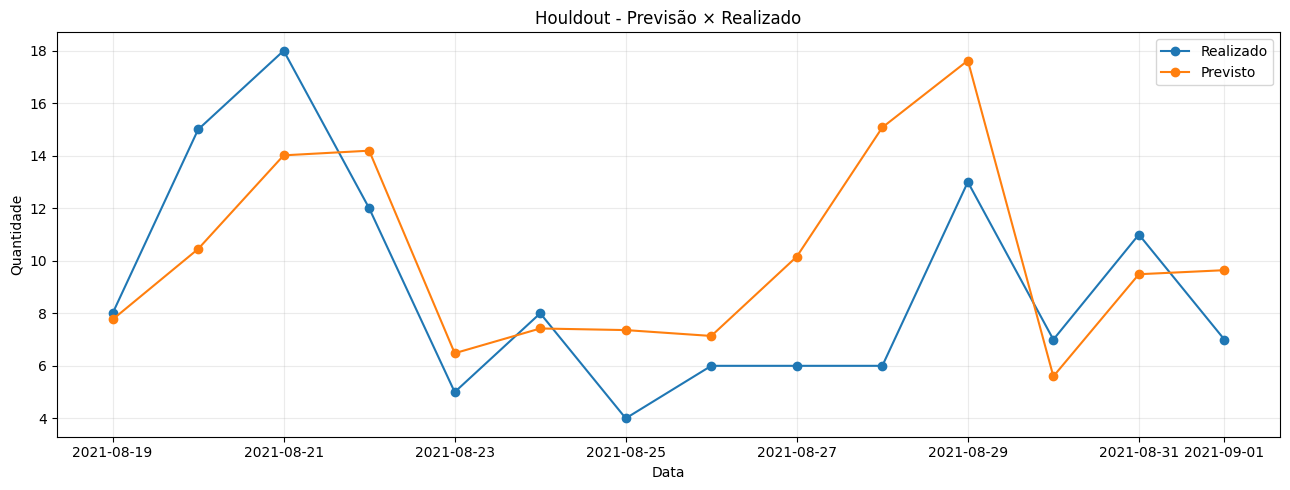

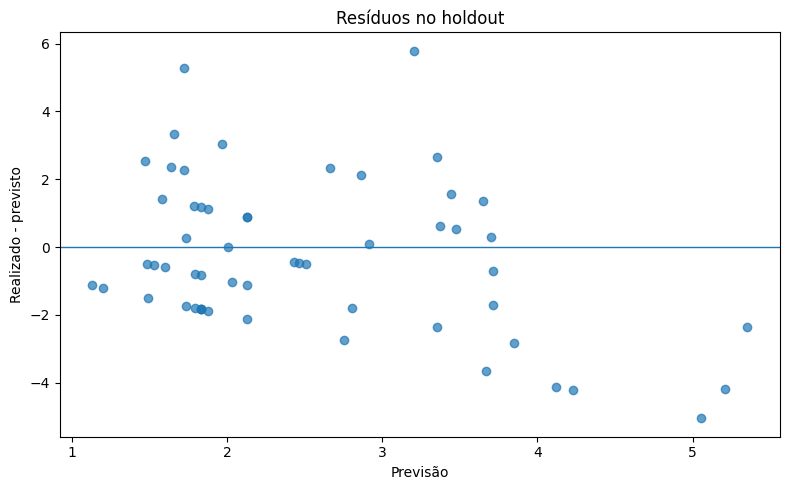

In [24]:
prev_holdout=holdout[['DATA','ID_ITEM','QUANTIDADE']].copy()
prev_holdout['PREVISAO']=pred_holdout
prev_holdout['RESIDUO']=prev_holdout.QUANTIDADE-prev_holdout.PREVISAO
prev_holdout['ERRO_ABSOLUTO']=prev_holdout.RESIDUO.abs()

graf=prev_holdout.groupby('DATA',as_index=False)[['QUANTIDADE','PREVISAO']].sum()
plt.figure(figsize=(13,5))
plt.plot(graf.DATA,graf.QUANTIDADE,marker='o',label='Realizado')
plt.plot(graf.DATA,graf.PREVISAO,marker='o',label='Previsto')
plt.title('Houldout - Previsão × Realizado')
plt.xlabel('Data'); plt.ylabel('Quantidade'); plt.legend(); plt.grid(alpha=.25)
plt.tight_layout(); plt.show()

plt.figure(figsize=(8,5))
plt.scatter(prev_holdout.PREVISAO,prev_holdout.RESIDUO,alpha=.7)
plt.axhline(0,linewidth=1)
plt.title('Resíduos no holdout')
plt.xlabel('Previsão'); plt.ylabel('Realizado - previsto')
plt.tight_layout(); plt.show()

,VARIAVEL,IMPORTANCIA_MEDIA,DESVIO
1,DIA_SEMANA,0.078,0.050
5,FIM_SEMANA,0.056,0.081
10,MEDIA_7,0.028,0.015
8,LAG_7,0.024,0.006
9,LAG_14,0.008,0.018
11,MEDIA_14,0.001,0.016
2,MES,0.000,0.000
13,MIN_7,0.000,0.000
4,SEMANA_ANO,0.000,0.000
3,INDICE_TEMPO,0.000,0.000


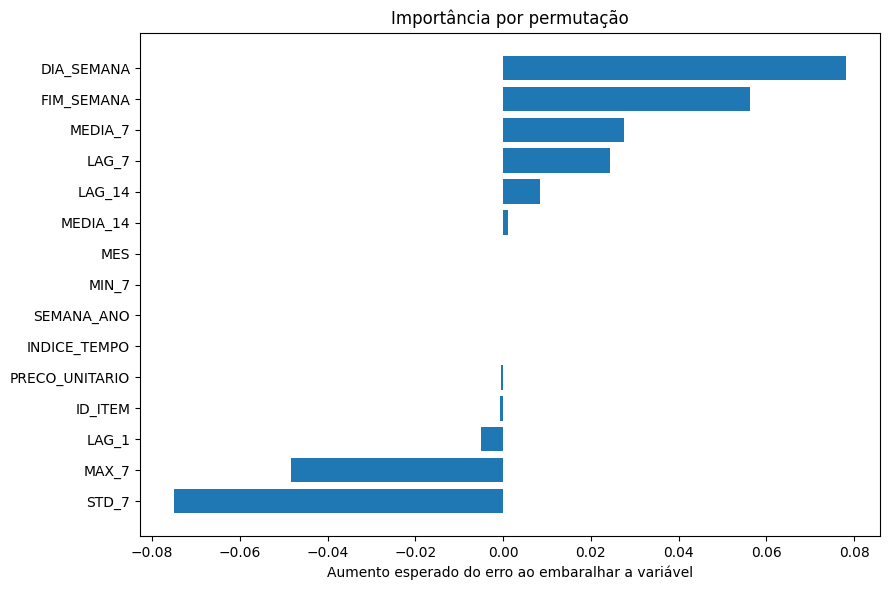

In [19]:
# Importância por permutação no holdout, aplicável a qualquer pipeline.
perm = permutation_importance(
    melhor_modelo, holdout[COLUNAS_MODELO], holdout.QUANTIDADE,
    scoring='neg_mean_absolute_error', n_repeats=8,
    random_state=RANDOM_STATE, n_jobs=-1
)
importancias = pd.DataFrame({
    'VARIAVEL': COLUNAS_MODELO,
    'IMPORTANCIA_MEDIA': perm.importances_mean,
    'DESVIO': perm.importances_std
}).sort_values('IMPORTANCIA_MEDIA',ascending=False)
display(importancias)

plt.figure(figsize=(9,6))
plt.barh(importancias.VARIAVEL[::-1],importancias.IMPORTANCIA_MEDIA[::-1])
plt.title('Importância por permutação')
plt.xlabel('Aumento esperado do erro ao embaralhar a variável')
plt.tight_layout(); plt.show()

## 7. Previsão recursiva dos próximos 7 dias

In [20]:
# Reajusta o melhor modelo em todo o histórico disponível.
modelo_final=modelos_candidatos()[melhor_nome]
modelo_final.fit(features[COLUNAS_MODELO],features.QUANTIDADE)

historicos={item:g.sort_values('DATA').QUANTIDADE.astype(float).tolist() for item,g in demanda.groupby('ID_ITEM')}
data_final=demanda.DATA.max()
indice_inicial=demanda.DATA.nunique()
buffer_q90=float(np.quantile(erros_cv.get(melhor_nome,[0]),.90))

linhas=[]
for passo in range(1,HORIZONTE_PREVISAO+1):
    data=data_final+pd.Timedelta(days=passo)
    for item in sorted(historicos):
        h=historicos[item]
        entrada=pd.DataFrame([{
            'ID_ITEM':item,
            'DIA_SEMANA':str(data.dayofweek),
            'MES':str(data.month),
            'INDICE_TEMPO':indice_inicial+passo-1,
            'SEMANA_ANO':int(data.isocalendar().week),
            'FIM_SEMANA':int(data.dayofweek>=5),
            'PRECO_UNITARIO':float(precos[item]),
            'LAG_1':h[-1], 'LAG_7':h[-7], 'LAG_14':h[-14],
            'MEDIA_7':float(np.mean(h[-7:])), 'MEDIA_14':float(np.mean(h[-14:])),
            'STD_7':float(np.std(h[-7:],ddof=1)), 'MIN_7':float(np.min(h[-7:])), 'MAX_7':float(np.max(h[-7:])),
        }])
        p=float(np.clip(modelo_final.predict(entrada)[0],0,None))
        h.append(p)
        linhas.append({
            'DATA':data,'ID_ITEM':item,'PREVISAO_DEMANDA':p,
            'BUFFER_Q90_ERRO_CV':buffer_q90,
            'ESTOQUE_SUGERIDO_ILUSTRATIVO':math.ceil(p+buffer_q90)
        })
previsao_7d=pd.DataFrame(linhas)
display(previsao_7d)

,DATA,ID_ITEM,PREVISAO_DEMANDA,BUFFER_Q90_ERRO_CV,ESTOQUE_SUGERIDO_ILUSTRATIVO
0,2021-09-02,item A,3.088,4.666,8
1,2021-09-02,item B,1.370,4.666,7
2,2021-09-02,item C,1.687,4.666,7
3,2021-09-02,item D,1.587,4.666,7
4,2021-09-03,item A,3.720,4.666,9
5,2021-09-03,item B,2.180,4.666,7
6,2021-09-03,item C,2.741,4.666,8
7,2021-09-03,item D,3.620,4.666,9
8,2021-09-04,item A,4.305,4.666,9
9,2021-09-04,item B,5.710,4.666,11


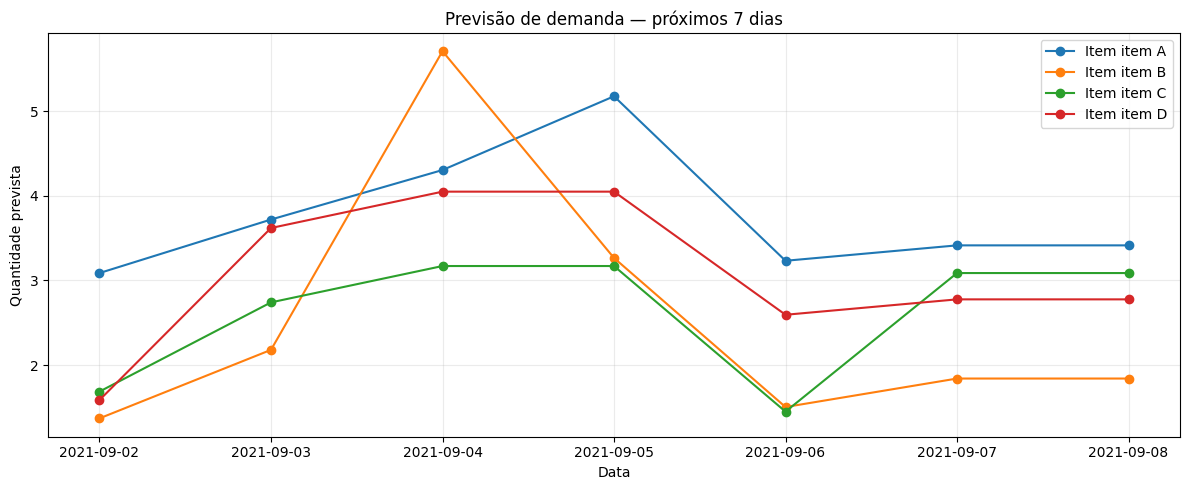

In [21]:
plt.figure(figsize=(12,5))
for item,g in previsao_7d.groupby('ID_ITEM'):
    plt.plot(g.DATA,g.PREVISAO_DEMANDA,marker='o',label=f'Item {item}')
plt.title('Previsão de demanda — próximos 7 dias')
plt.xlabel('Data'); plt.ylabel('Quantidade prevista'); plt.legend(); plt.grid(alpha=.25)
plt.tight_layout(); plt.show()